In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score
import joblib

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
df.info()
df.isnull().sum()
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')  # NaN means no disorder in this dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [3]:
df[['BP_Systolic', 'BP_Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Blood Pressure'], inplace=True)

In [4]:
if 'Person ID' in df.columns:
    df.drop(columns=['Person ID'], inplace=True)

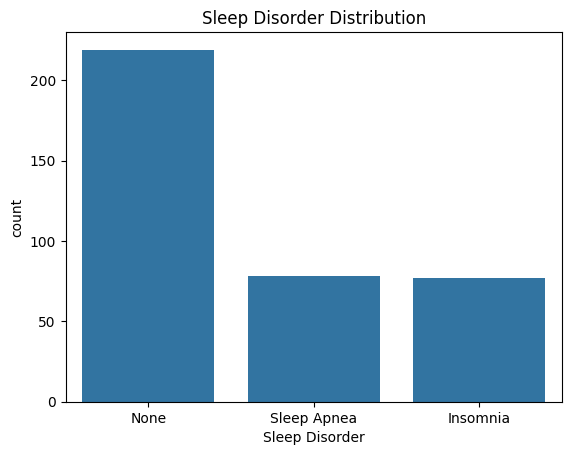

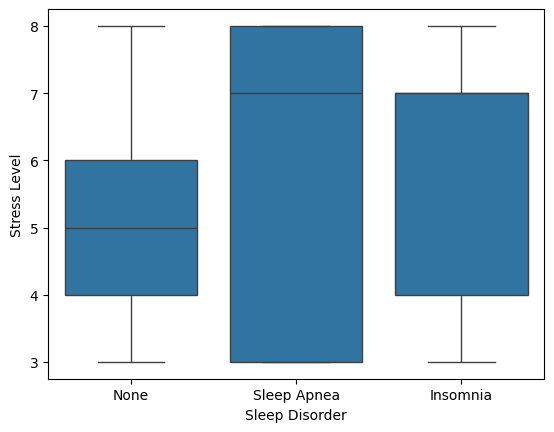

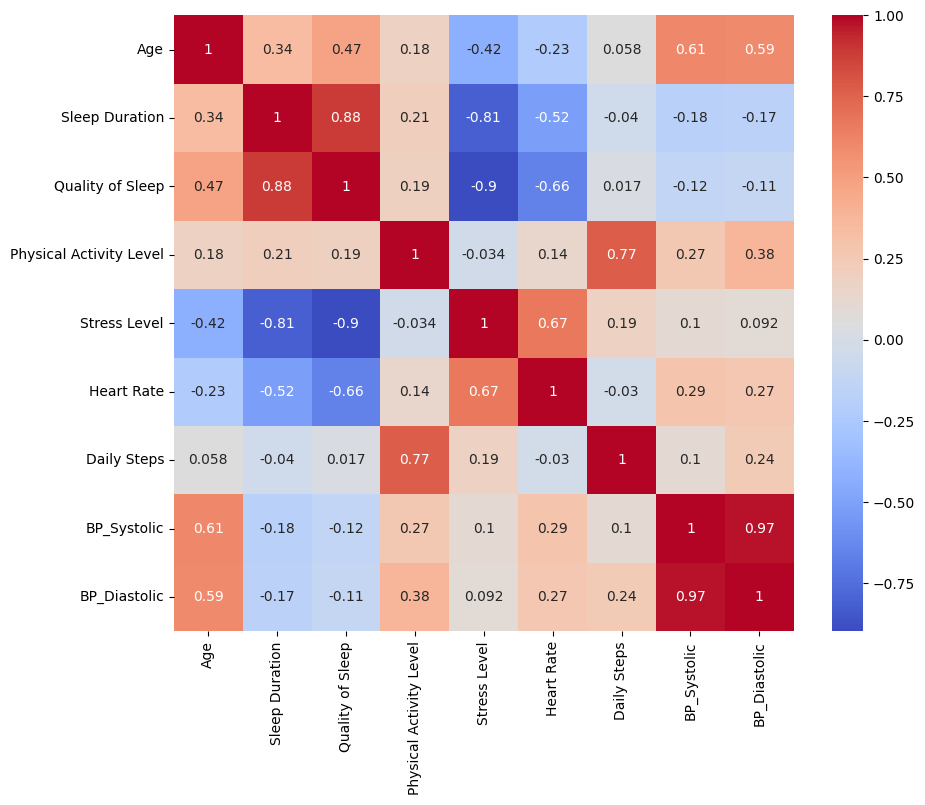

In [5]:
sns.countplot(data=df, x='Sleep Disorder')
plt.title('Sleep Disorder Distribution')
plt.show()

sns.boxplot(data=df, x='Sleep Disorder', y='Stress Level')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

In [6]:
categorical_cols = ['Gender', 'Occupation', 'BMI Category']
le_dict = {}
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le  # save encoders, you'll need them in the Streamlit app

# Encode target separately
target_le = LabelEncoder()
df_encoded['Sleep Disorder'] = target_le.fit_transform(df_encoded['Sleep Disorder'])

              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75



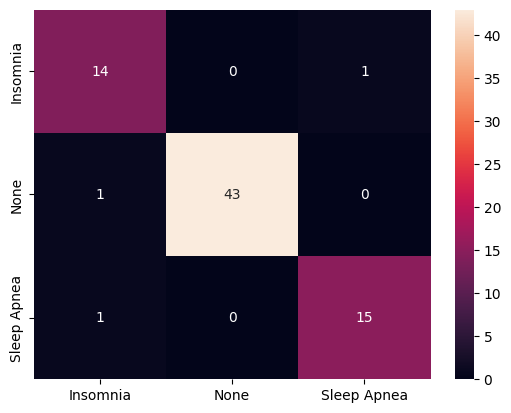

In [7]:
feature_cols = ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
                 'Physical Activity Level', 'Stress Level', 'BMI Category',
                 'Heart Rate', 'Daily Steps', 'BP_Systolic', 'BP_Diastolic']

X = df_encoded[feature_cols]
y = df_encoded['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=target_le.classes_))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.show()

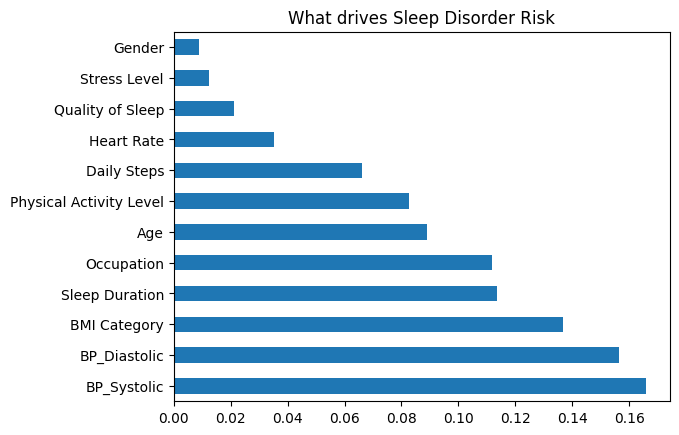

In [8]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot(kind='barh')
plt.title('What drives Sleep Disorder Risk')
plt.show()

In [9]:
reg_features = ['Gender', 'Age', 'Occupation', 'Sleep Duration',
                 'Physical Activity Level', 'Stress Level', 'BMI Category',
                 'Heart Rate', 'Daily Steps', 'BP_Systolic', 'BP_Diastolic']

X_reg = df_encoded[reg_features]
y_reg = df_encoded['Quality of Sleep']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(Xr_train, yr_train)

yr_pred = reg.predict(Xr_test)
print("MAE:", mean_absolute_error(yr_test, yr_pred))
print("R²:", r2_score(yr_test, yr_pred))

MAE: 0.04226666666666663
R²: 0.987224988215885


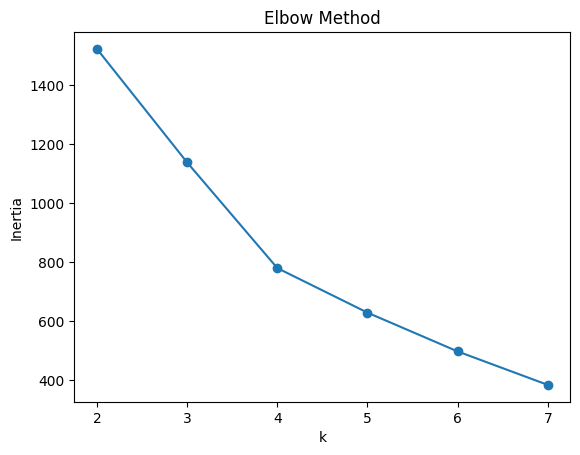

In [10]:
cluster_features = ['Age', 'Sleep Duration', 'Physical Activity Level',
                     'Stress Level', 'Heart Rate', 'Daily Steps']

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_encoded[cluster_features])

# Find a good k
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.plot(range(2,8), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_encoded['Lifestyle_Cluster'] = kmeans.fit_predict(X_cluster)

df_encoded.groupby('Lifestyle_Cluster')[cluster_features].mean()

,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Lifestyle_Cluster,,,,,,
0,38.005882,7.345294,66.382353,4.776471,68.294118,7331.764706
1,48.470588,6.073529,88.235294,8.000000,75.000000,10000.000000
2,38.368932,6.399029,41.067961,7.058252,73.980583,5399.029126
3,55.462687,8.255224,53.955224,3.029851,66.597015,6074.626866


In [12]:
joblib.dump(clf, 'disorder_model.pkl')
joblib.dump(reg, 'quality_model.pkl')
joblib.dump(kmeans, 'cluster_model.pkl')
joblib.dump(scaler, 'cluster_scaler.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
joblib.dump(target_le, 'target_encoder.pkl')

['target_encoder.pkl']